## Seaborn cheat sheet :)

**1. How Seaborn Works the data=, x=, y=, hue= pattern**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Load the Employees sheet from the TechCorp workbook
df = pd.read_excel("TechCorp_Cleaned.xlsx", sheet_name="Employees")

# Step 2: Preview relevant columns we'll use for this example
print(df[["department", "salary", "Seniority"]].head())

    department      salary  Seniority
0        Sales  119704.350     Senior
1           HR   54396.610  Mid-Level
2           HR   55221.150     Senior
3  Engineering  119468.820     Senior
4      Finance  105906.865  Mid-Level


    department      salary  Seniority
0        Sales  119704.350     Senior
1           HR   54396.610  Mid-Level
2           HR   55221.150     Senior
3  Engineering  119468.820     Senior
4      Finance  105906.865  Mid-Level


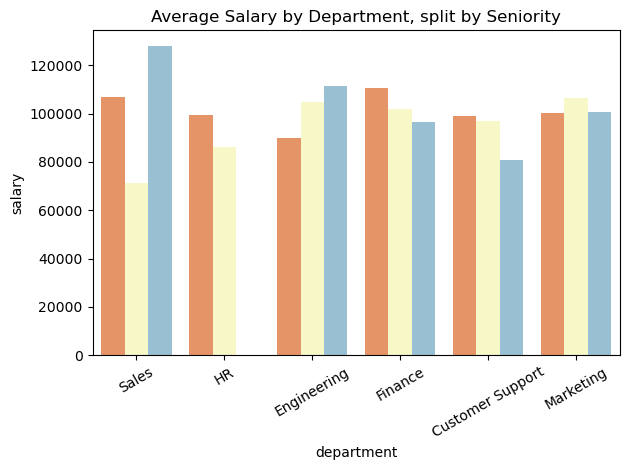

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Load the Employees sheet from the TechCorp workbook
df = pd.read_excel("TechCorp_Cleaned.xlsx", sheet_name="Employees")

# Step 2: Preview relevant columns we'll use for this example
print(df[["department", "salary", "Seniority"]].head())

# Step 3: Create a simple bar plot the "Seaborn way"
# Instead of extracting arrays manually, we just pass the dataframe
# and tell Seaborn which COLUMN NAMES to use
sns.barplot(
    data=df,          # the dataframe itself
    x="department",   # column name -> x-axis
    y="salary",       # column name -> y-axis
    errorbar=None,       
    hue="Seniority",   # column name -> splits each department's bar into sub-groups
    palette="RdYlBu",
    legend=False,
)

# Step 4: Add labels and show the plot
plt.title("Average Salary by Department, split by Seniority")
plt.xticks(rotation=30)  # rotate x labels so department names don't overlap
plt.tight_layout()

plt.show()

**2. Seaborn Themes and Context set_theme(), set_context(), set_palette()**

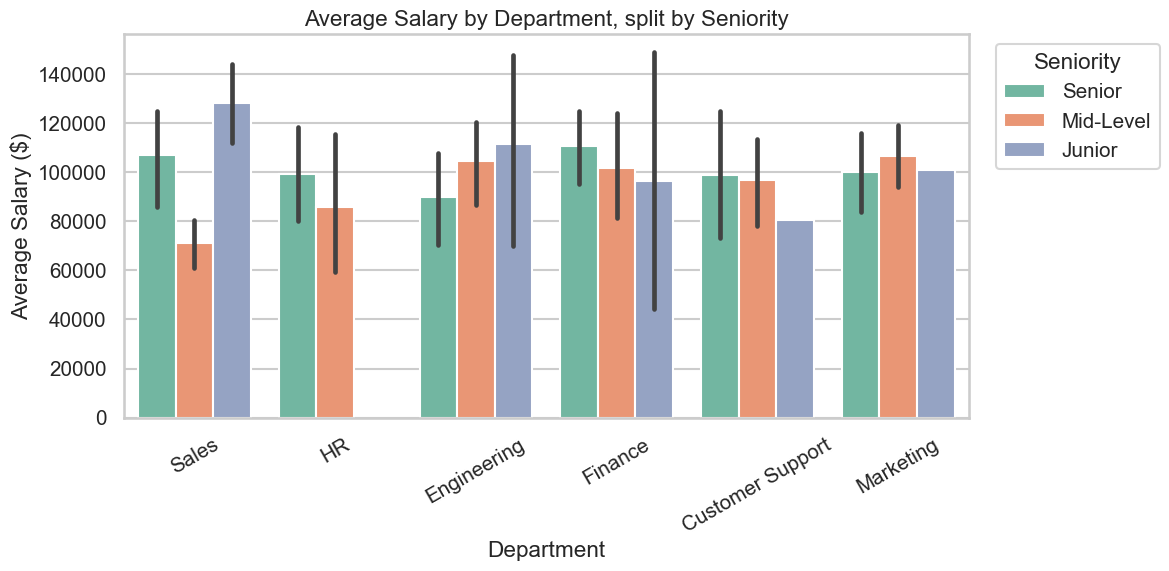

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Load the Employees sheet
df = pd.read_excel("TechCorp_Cleaned.xlsx", sheet_name="Employees")

# Step 2: Set a global theme ONCE — affects every plot drawn after this line
sns.set_theme(
    style="whitegrid",   # clean white background with light gridlines
    palette="Set2"       # default color scheme for categorical hues
)

# Step 3: Set the context — this chart is meant for a presentation/talk
sns.set_context("talk", font_scale=0.9)  # larger fonts, slightly scaled down

# Step 4: Create the figure canvas EXPLICITLY, with enough room for
# 6 departments x 3 Seniority levels = 18 bars, at "talk" font sizes
plt.figure(figsize=(12, 6))

# Step 5: Draw the plot — it automatically inherits theme + context set above
sns.barplot(data=df, x="department", y="salary", hue="Seniority")

# Step 6: Titles and axis labels
plt.title("Average Salary by Department, split by Seniority")
plt.xlabel("Department")
plt.ylabel("Average Salary ($)")
plt.xticks(rotation=30)  # rotate department names so they don't overlap

# Step 7: Move the legend OUTSIDE the plot area so it doesn't cover bars
plt.legend(title="Seniority", bbox_to_anchor=(1.02, 1), loc="upper left")

# Step 8: tight_layout() recalculates spacing so nothing gets clipped
# (rotated labels, legend outside the axes, etc.)
plt.tight_layout()

plt.show()

**3. countplot()**

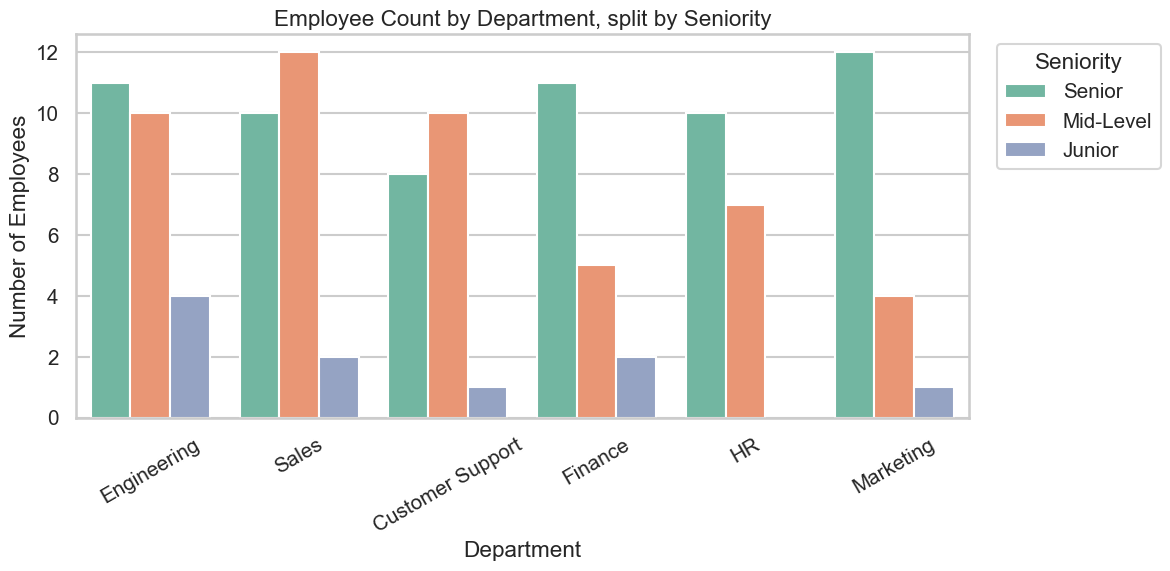

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Load the Employees sheet
df = pd.read_excel("TechCorp_Cleaned.xlsx", sheet_name="Employees")

# Step 2: Set the global look — done once per session
sns.set_theme(style="whitegrid")
sns.set_context("talk", font_scale=0.9)

# Step 3: Compute department order by total employee count (largest first)
# This makes the chart easier to read than default alphabetical order
dept_order = df["department"].value_counts().index

# Step 4: Create the figure canvas with enough width for 6 departments x 3 hues
plt.figure(figsize=(12, 6))

# Step 5: Draw the countplot
# no "y=" here — countplot calculates the bar heights (counts) itself
sns.countplot(
    data=df,
    x="department",     # column whose categories go on x-axis
    hue="Seniority",    # splits each department's bar into Junior/Mid/Senior
    order=dept_order,   # departments sorted by total headcount, largest first
    palette="Set2"      # color scheme for the 3 Seniority sub-bars
)

# Step 6: Titles and labels
plt.title("Employee Count by Department, split by Seniority")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=30)

# Step 7: Move legend outside so it doesn't overlap bars
plt.legend(title="Seniority", bbox_to_anchor=(1.02, 1), loc="upper left")

# Step 8: Recalculate layout so nothing gets clipped
plt.tight_layout()

plt.show()

**4. Barplot()**

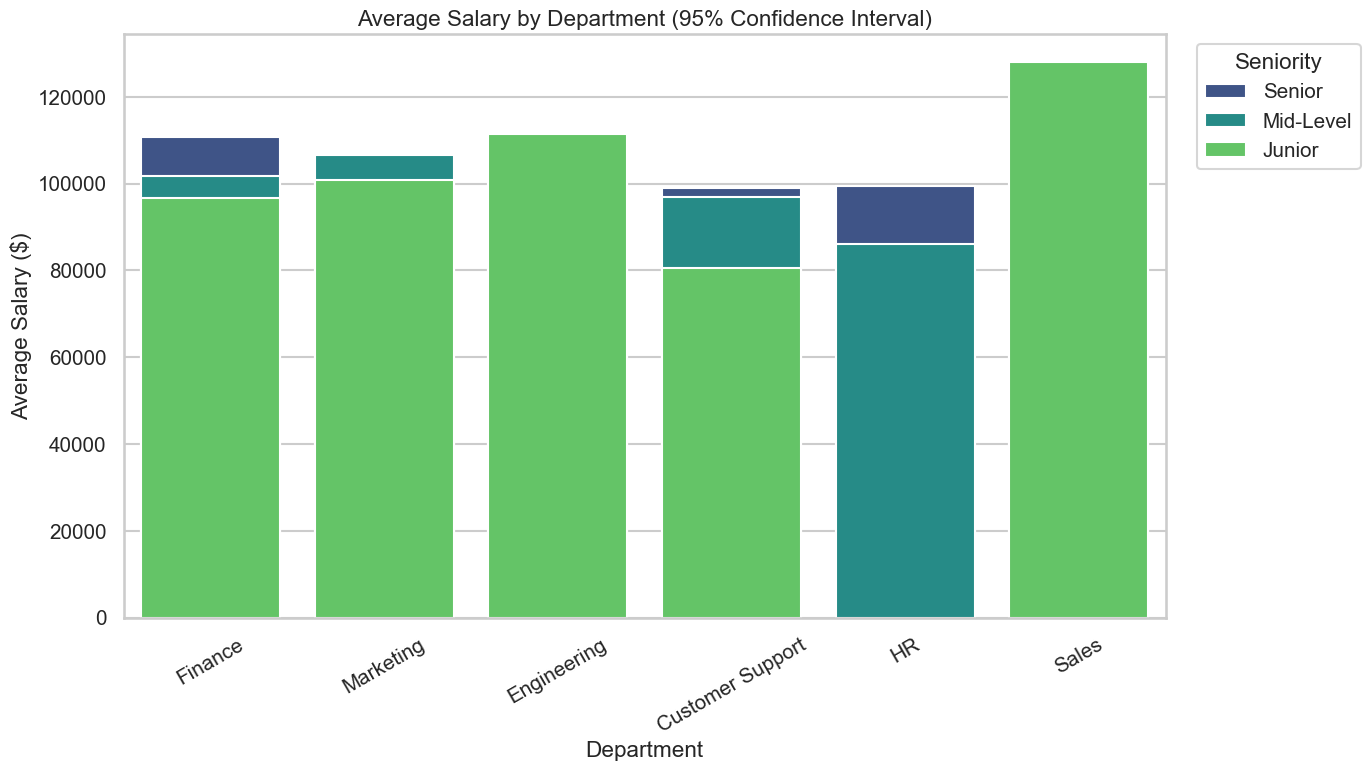

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Load the Employees sheet
df = pd.read_excel("TechCorp_Cleaned.xlsx", sheet_name="Employees")

# Step 2: Global theme/context — set once per session
sns.set_theme(style="whitegrid")
sns.set_context("talk", font_scale=0.9)

# Step 3: Order departments by average salary (highest first) so the
# chart reads like a ranking rather than random/alphabetical order
dept_order = (
    df.groupby("department")["salary"]
    .mean()
    .sort_values(ascending=False)
    .index
)

# Step 4: Create the figure canvas
plt.figure(figsize=(14, 8))

# Step 5: Draw the barplot
sns.barplot(
    data=df,
    x="department",        # category on x-axis
    y="salary",             # numeric column being averaged
    order=dept_order,       # departments ranked by avg salary, highest first
    estimator="mean",       # bar height = average salary (explicit, though it's the default)
    # capsize=0.15,           # adds small caps to the error bars, easier to read
    color="steelblue",      # single flat color since we're not using hue here
    dodge=False,
    hue="Seniority",
    palette="viridis",
    errorbar=None,
    saturation=0.9

)

# Step 6: Titles and labels
plt.title("Average Salary by Department (95% Confidence Interval)")
plt.xlabel("Department")
plt.ylabel("Average Salary ($)")
plt.xticks(rotation=30)
plt.legend(title="Seniority", bbox_to_anchor=(1.02, 1), loc="upper left")


# Step 7: Clean up spacing
plt.tight_layout()

plt.show()

**5. Boxplot()**

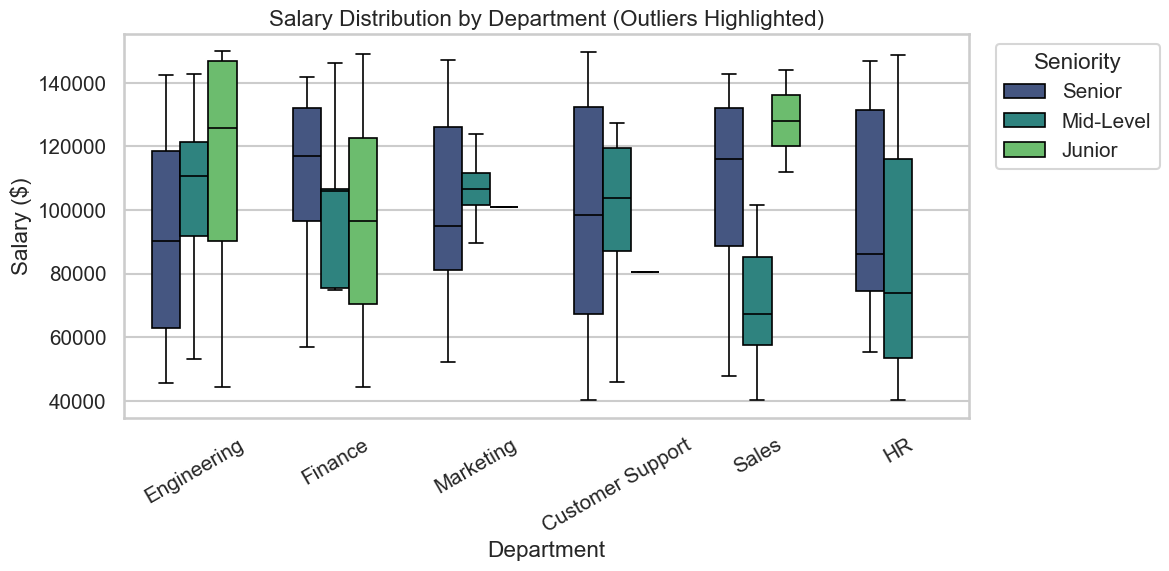

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Load the Employees sheet
df = pd.read_excel("TechCorp_Cleaned.xlsx", sheet_name="Employees")

# Step 2: Global theme/context
sns.set_theme(style="whitegrid")
sns.set_context("talk", font_scale=0.9)

# Step 3: Order departments by median salary (boxplot median, not mean)
# so departments are ranked by their "typical" salary, high to low
dept_order = (
    df.groupby("department")["salary"]
    .median()
    .sort_values(ascending=False)
    .index
)

# Step 4: Create the figure canvas
plt.figure(figsize=(12, 6))

# Step 5: Draw the boxplot
sns.boxplot(
    data=df,
    x="department",          # category on x-axis
    y="salary",              # numeric distribution being summarized
    order=dept_order,        # departments ranked by median salary
    whis=1.5,                 # standard Tukey rule: whiskers = 1.5 x IQR beyond the box
    color="skyblue",          # single flat color (no hue split in this example)
    linecolor="black",        # box outline / median line / whiskers drawn in black
    linewidth=1.2,             # slightly thicker lines for visibility at "talk" context
    fliersize=6,               # outlier dots drawn a bit larger so they're easy to spot
    width=0.6,                  # slightly narrower boxes, leaves breathing room between departments
    hue="Seniority",
    palette='viridis'
)

# Step 6: Titles and labels
plt.title("Salary Distribution by Department (Outliers Highlighted)")
plt.xlabel("Department")
plt.ylabel("Salary ($)")
plt.xticks(rotation=30)
plt.legend(title="Seniority", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

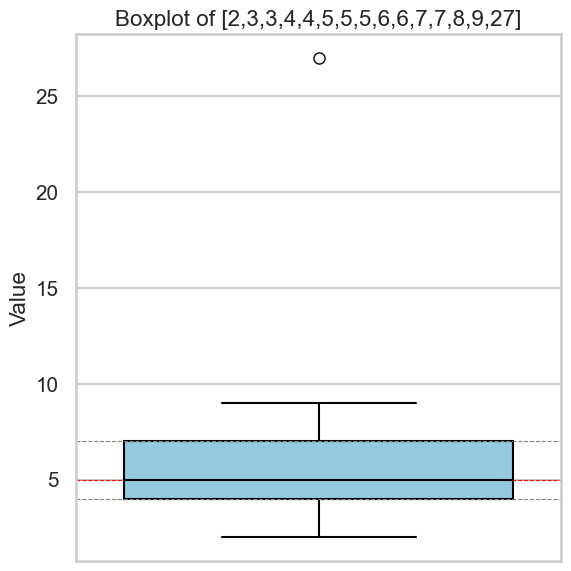

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Our hand-picked dataset — 14 normal values (1-9) + 1 outlier (27)
data = [2, 3, 3, 4, 4, 5, 5, 5, 6, 6, 7, 7, 8, 9, 27]

# Step 2: Wrap it in a DataFrame — Seaborn expects a "column" to plot from
df_demo = pd.DataFrame({"value": data})

# Step 3: Theme setup
sns.set_theme(style="whitegrid")
sns.set_context("talk", font_scale=0.9)

plt.figure(figsize=(6, 6))

# Step 4: Draw the boxplot using the exact same whis=1.5 rule we calculated by hand
sns.boxplot(
    data=df_demo,
    y="value",
    whis=1.5,           # matches our hand-calculated fences
    color="skyblue",
    linecolor="black",
    linewidth=1.5,
    fliersize=8          # make the outlier dot obvious
)

# Step 5: Annotate the plot with our hand-calculated numbers for teaching clarity
plt.axhline(4, color="gray", linestyle="--", linewidth=0.8)   # Q1
plt.axhline(5, color="red", linestyle="--", linewidth=0.8)    # Median
plt.axhline(7, color="gray", linestyle="--", linewidth=0.8)   # Q3

plt.title("Boxplot of [2,3,3,4,4,5,5,5,6,6,7,7,8,9,27]")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

**6. violineplot()**

C:\Users\hp\AppData\Local\Temp\ipykernel_24440\1262784688.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


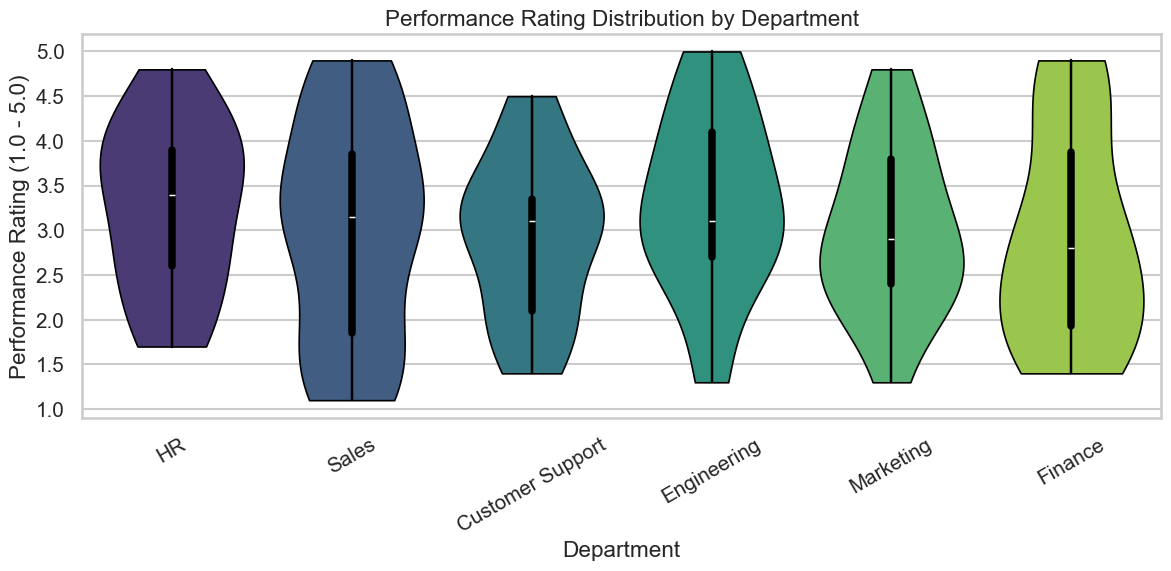

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Load the Employees sheet
df = pd.read_excel("TechCorp_Cleaned.xlsx", sheet_name="Employees")

# Step 2: Global theme/context
sns.set_theme(style="whitegrid")
sns.set_context("talk", font_scale=0.9)

# Step 3: Order departments by median performance rating, highest first
dept_order = (
    df.groupby("department")["performance_rating"]
    .median()
    .sort_values(ascending=False)
    .index
)

# Step 4: Create the figure canvas
plt.figure(figsize=(12, 6))

# Step 5: Draw the violin plot
sns.violinplot(
    data=df,
    x="department",              # category on x-axis
    y="performance_rating",      # numeric distribution (ratings run 1.0 - 5.0)
    order=dept_order,            # departments ranked by median rating
    # inner="box",                 # show a mini boxplot (median + IQR) inside each violin
    cut=0,                       # clip violin tails exactly to real data range —
                                  # ratings can't go below 1 or above 5, so don't invent tails past that
    bw_adjust=1,                 # default smoothing — increase if the shape looks too "spiky"
    color="lightcoral",
    linewidth=1.2,
    linecolor="black",
    palette='viridis'
)

# Step 6: Titles and labels
plt.title("Performance Rating Distribution by Department")
plt.xlabel("Department")
plt.ylabel("Performance Rating (1.0 - 5.0)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

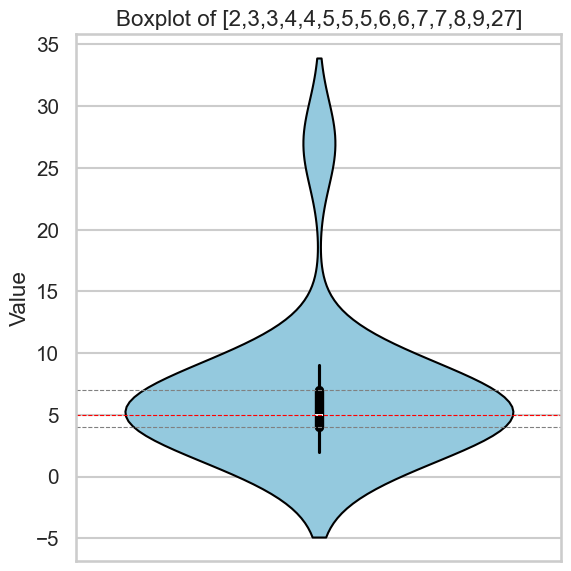

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Our hand-picked dataset — 14 normal values (1-9) + 1 outlier (27)
data = [2, 3, 3, 4, 4, 5, 5, 5, 6, 6, 7, 7, 8, 9, 27]

# Step 2: Wrap it in a DataFrame — Seaborn expects a "column" to plot from
df_demo = pd.DataFrame({"value": data})

# Step 3: Theme setup
sns.set_theme(style="whitegrid")
sns.set_context("talk", font_scale=0.9)

plt.figure(figsize=(6, 6))

# Step 4: Draw the boxplot using the exact same whis=1.5 rule we calculated by hand
sns.violinplot(
    data=df_demo,
    y="value",
    color="skyblue",
    linecolor="black",
    linewidth=1.5,

)

# Step 5: Annotate the plot with our hand-calculated numbers for teaching clarity
plt.axhline(4, color="gray", linestyle="--", linewidth=0.8)   # Q1
plt.axhline(5, color="red", linestyle="--", linewidth=0.8)    # Median
plt.axhline(7, color="gray", linestyle="--", linewidth=0.8)   # Q3

plt.title("Boxplot of [2,3,3,4,4,5,5,5,6,6,7,7,8,9,27]")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

**6. strip and swarmplots**

C:\Users\hp\AppData\Local\Temp\ipykernel_24440\1945089168.py:31: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


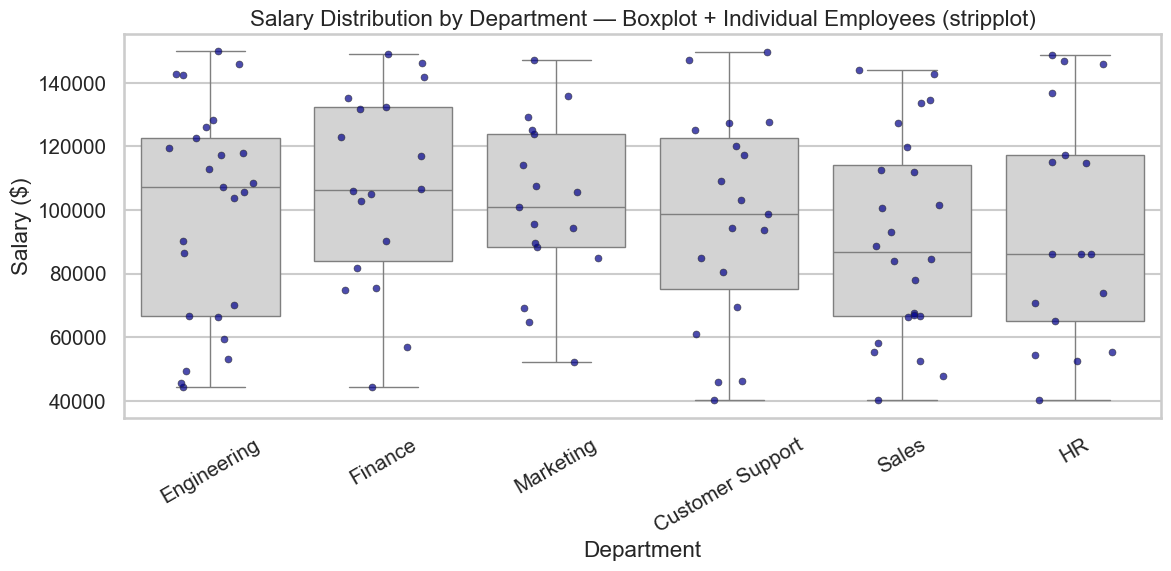

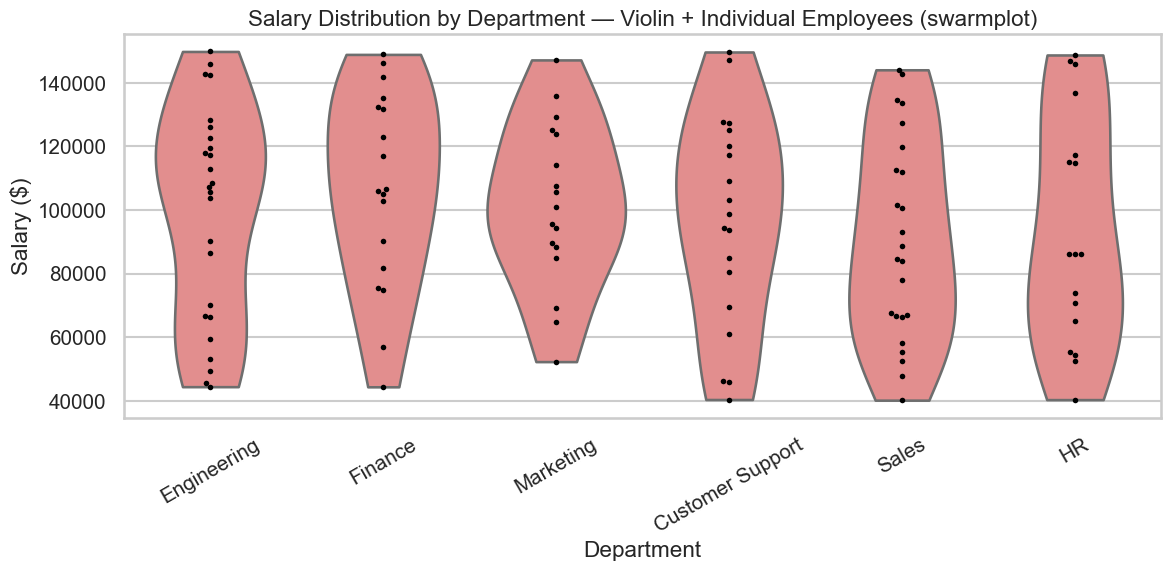

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Load the Employees sheet
df = pd.read_excel("TechCorp_Cleaned.xlsx", sheet_name="Employees")

# Step 2: Global theme/context
sns.set_theme(style="whitegrid")
sns.set_context("talk", font_scale=0.9)

# Step 3: Order departments by median salary
dept_order = (
    df.groupby("department")["salary"]
    .median()
    .sort_values(ascending=False)
    .index
)

# --- Chart A: stripplot overlaid on a boxplot ---
plt.figure(figsize=(12, 6))

# Step 4a: Draw the boxplot first as the "summary" background layer
sns.boxplot(
    data=df, x="department", y="salary", order=dept_order,
    color="lightgray", fliersize=0   # fliersize=0 hides boxplot's own outlier dots
                                       # since stripplot will show ALL real points instead
)

# Step 4b: Overlay every individual employee's salary as a jittered point
sns.stripplot(
    data=df,
    x="department",
    y="salary",
    order=dept_order,
    jitter=0.25,        # moderate horizontal scatter so points don't stack in one line
    size=5,
    color="darkblue",
    edgecolor="gray",
    linewidth=0.5,
    alpha=0.7           # slight transparency so overlapping points are still visible
)

plt.title("Salary Distribution by Department — Boxplot + Individual Employees (stripplot)")
plt.xlabel("Department")
plt.ylabel("Salary ($)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# --- Chart B: swarmplot overlaid on a violinplot ---
plt.figure(figsize=(12, 6))

# Step 5a: Draw the violin shape first as the "summary" background layer
sns.violinplot(
    data=df, x="department", y="salary", order=dept_order,
    inner=None,           # turn OFF the violin's own inner box —
                           # swarmplot will supply the individual points instead
    color="lightcoral", cut=0
)

# Step 5b: Overlay every individual point, precisely non-overlapping
sns.swarmplot(
    data=df,
    x="department",
    y="salary",
    order=dept_order,
    size=4,               # smaller points so the swarm fits comfortably within each violin
    color="black"
)

plt.title("Salary Distribution by Department — Violin + Individual Employees (swarmplot)")
plt.xlabel("Department")
plt.ylabel("Salary ($)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**7. Histogram**

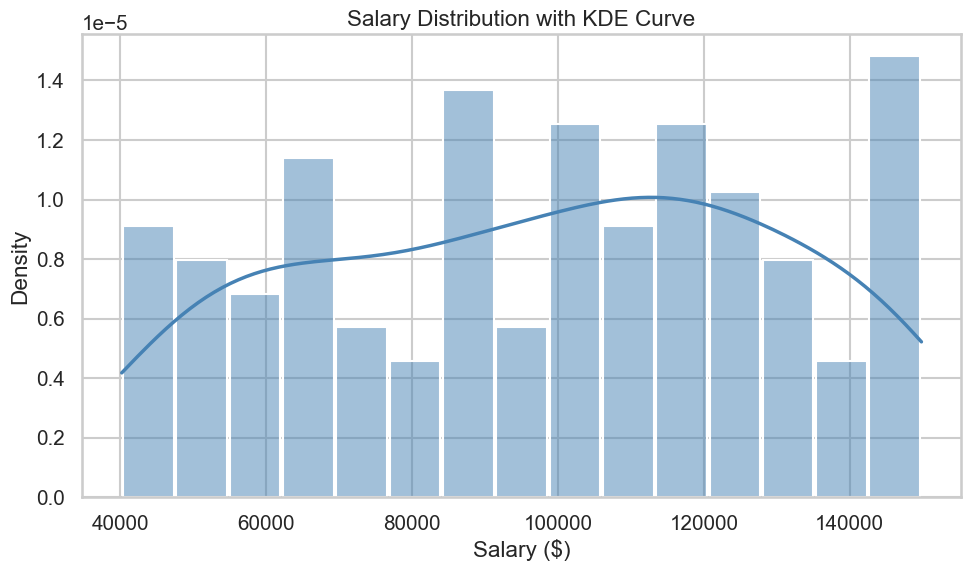

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Load the Employees sheet
df = pd.read_excel("TechCorp_Cleaned.xlsx", sheet_name="Employees")

# Step 2: Global theme/context
sns.set_theme(style="whitegrid")
sns.set_context("talk", font_scale=0.9)

plt.figure(figsize=(10, 6))

# Step 3: Draw the histogram with a KDE curve overlaid
sns.histplot(
    data=df,
    x="salary",              # numeric column being binned
    stat="density",          # IMPORTANT: must be "density" so the bar heights are
                              # on the same scale as the KDE curve (both integrate to 1)
    bins=15,                 # fixed number of bins — good starting point for ~120 rows
    kde=True,                # overlay the smoothed density curve
    kde_kws={"bw_adjust": 1, "cut": 0},   # cut=0 stops the KDE from drawing
                                            # a tail into impossible negative-salary territory
    line_kws={"color": "red", "linewidth": 2.5},  # style the KDE line to stand out
    color="steelblue",
    edgecolor="white",       # thin white borders between bars for visual separation
    shrink=0.95               # tiny gap between bars, slightly cleaner look
)

# Step 4: Titles and labels
plt.title("Salary Distribution with KDE Curve")
plt.xlabel("Salary ($)")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

**8. KDE plot**

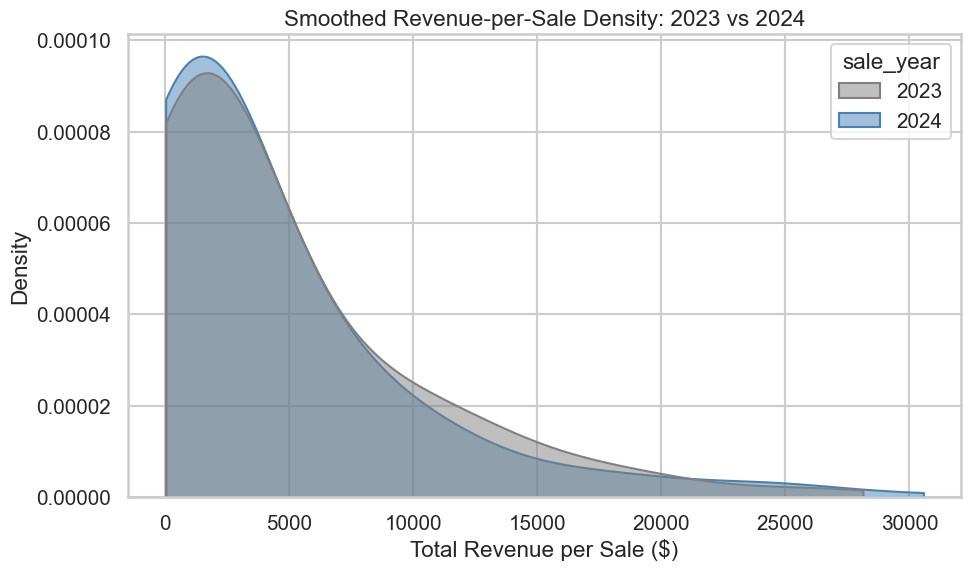

In [59]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Load the Sales sheet (has sale_year: 2023 and 2024)
sales = pd.read_excel("TechCorp_Cleaned.xlsx", sheet_name="Sales")

# Step 2: Global theme/context
sns.set_theme(style="whitegrid")
sns.set_context("talk", font_scale=0.9)

plt.figure(figsize=(10, 6))

# Step 3: Draw two overlaid KDE curves — one per sale_year, via hue
sns.kdeplot(
    data=sales,
    x="total_revenue",         # numeric column being compared across years
    hue="sale_year",           # splits into two curves: 2023 and 2024
    fill=True,                 # shade the area under each curve
    common_norm=False,         # each year's curve normalized independently —
    multiple="layer",
    # cumulative=True,
    bw_adjust=1.5,                # default smoothing
    cut=0,                      # don't let the curve dip below the real data range
    clip=(0, None),              # hard rule: revenue can never be negative
    palette={2023: "gray", 2024: "steelblue"},  # explicit colors: old year muted, new year highlighted
    alpha=0.5                    # transparency so overlapping shaded areas are both visible
)

# Step 4: Titles and labels
plt.title("Smoothed Revenue-per-Sale Density: 2023 vs 2024")
plt.xlabel("Total Revenue per Sale ($)")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

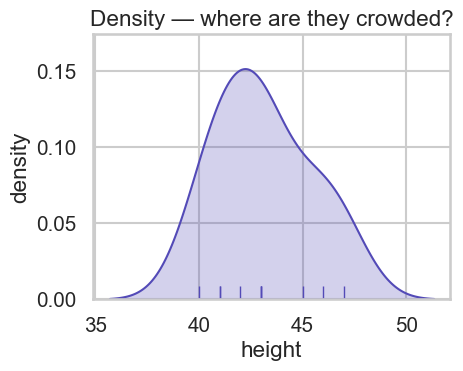

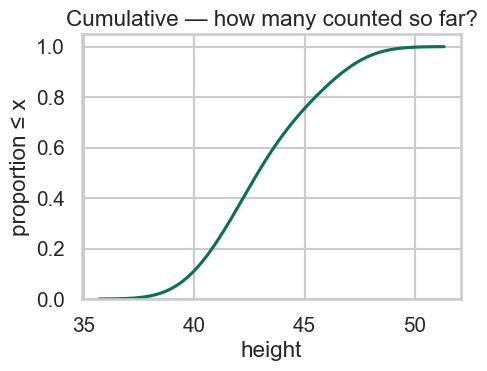

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

heights = [40, 41, 41, 42, 43, 43, 43, 45, 46, 47]

# --- Plot 1: density (axes-level) ---
fig1, ax1 = plt.subplots(figsize=(5, 4))
sns.kdeplot(x=heights, fill=True, color="#534AB7", ax=ax1)
sns.rugplot(x=heights, color="#534AB7", height=0.05, ax=ax1)
ax1.set_title("Density — where are they crowded?")
ax1.set_xlabel("height")
ax1.set_ylabel("density")
plt.tight_layout()
plt.show()

# --- Plot 2: cumulative (axes-level) ---
fig2, ax2 = plt.subplots(figsize=(5, 4))
sns.kdeplot(x=heights, cumulative=True, color="#0F6E56", ax=ax2)
ax2.set_title("Cumulative — how many counted so far?")
ax2.set_xlabel("height")
ax2.set_ylabel("proportion ≤ x")
plt.tight_layout()
plt.show()

**9. Scatterplot**

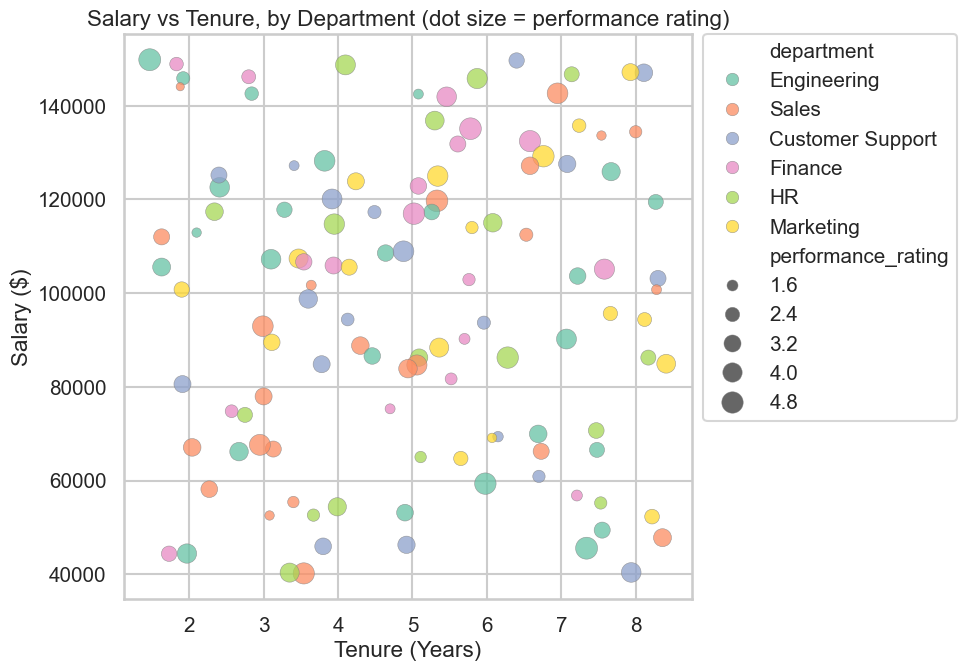

In [61]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Load the Employees sheet
df = pd.read_excel("TechCorp_Cleaned.xlsx", sheet_name="Employees")

# Step 2: Global theme/context
sns.set_theme(style="whitegrid")
sns.set_context("talk", font_scale=0.9)

plt.figure(figsize=(10, 7))

# Step 3: Draw the scatterplot
sns.scatterplot(
    data=df,
    x="tenure_years",          # numeric: years at the company
    y="salary",                 # numeric: employee's salary
    hue="department",           # colors dots by department (6 categories)
    hue_order=df["department"].value_counts().index,  # legend ordered by headcount
    # style="Seniority",          # ALSO varies marker shape by Seniority —
                                  # redundant with color-adjacent info, but improves
                                  # readability/accessibility beyond color alone
    size="performance_rating",  # bigger dots = higher-rated employees
    sizes=(30, 250),             # smallest dot = 30pt, largest = 250pt
    size_norm=(1, 5),            # matches performance_rating's real 1-5 scale,
                                   # so sizing is meaningful, not just relative to this chart's data
    palette="Set2",
    alpha=0.75,                   # slight transparency — helps when points overlap
    edgecolor="gray",
    linewidth=0.4
)

# Step 4: Titles and labels
plt.title("Salary vs Tenure, by Department (dot size = performance rating)")
plt.xlabel("Tenure (Years)")
plt.ylabel("Salary ($)")

# Step 5: Move legend outside — with hue + style + size combined,
# the legend is large and would otherwise cover data points
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)

plt.tight_layout()
plt.show()

**10. regplot and lmplot**

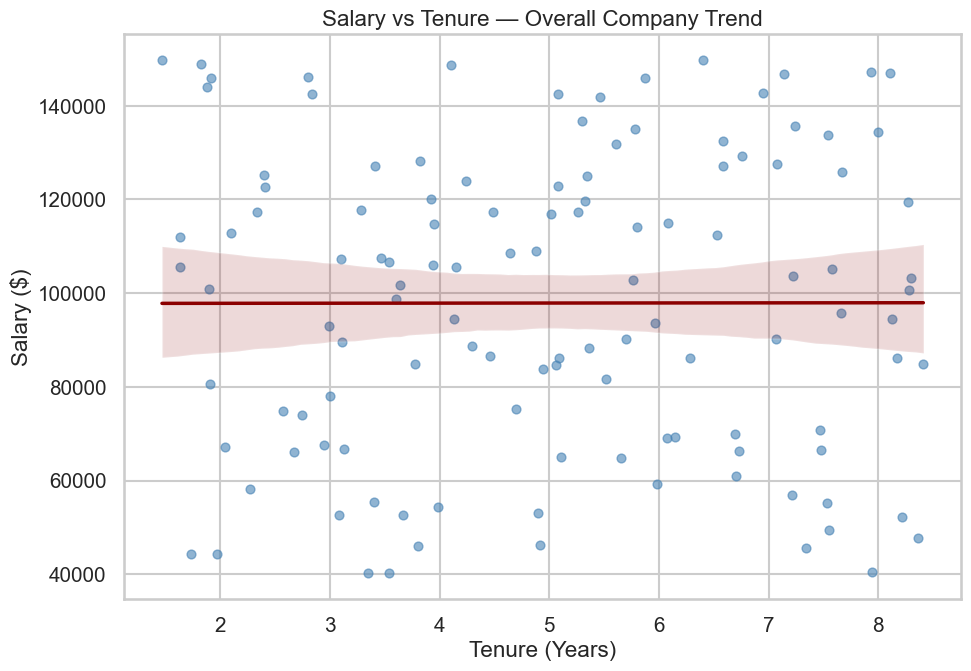

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Load the Employees sheet
df = pd.read_excel("TechCorp_Cleaned.xlsx", sheet_name="Employees")

# Step 2: Global theme/context
sns.set_theme(style="whitegrid")
sns.set_context("talk", font_scale=0.9)

# --- Chart A: regplot — one overall trend line for the whole company ---
plt.figure(figsize=(10, 7))

sns.regplot(
    data=df,
    x="tenure_years",         # years at the company
    y="salary",                # salary being predicted from tenure
    order=1,   
    # lowess=True,                                # straight-line (linear) fit — our starting assumption
    ci=95,                      # shaded 95% confidence band around the fitted line 
    truncate=True,               # don't extrapolate the line past our real tenure range
    scatter_kws={"alpha": 0.6, "s": 40, "color": "steelblue"},  # style the raw points
    line_kws={"color": "darkred", "linewidth": 2.5}              # style the trend line
)

plt.title("Salary vs Tenure — Overall Company Trend")
plt.xlabel("Tenure (Years)")
plt.ylabel("Salary ($)")
plt.tight_layout()
plt.show()

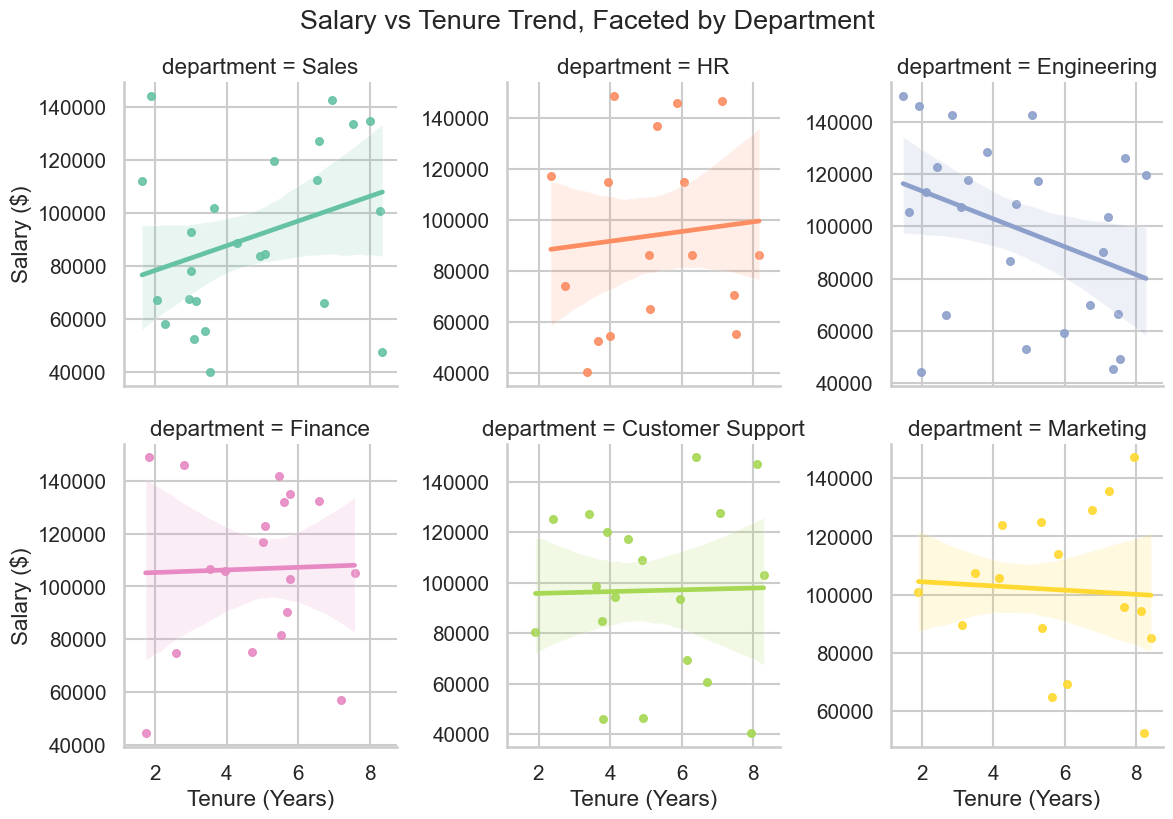

In [25]:
# --- Chart B: lmplot — one regression line PER department, faceted into panels ---
# NOTE: lmplot creates its OWN figure — don't call plt.figure() before it
g = sns.lmplot(
    data=df,
    x="tenure_years",
    y="salary",
    col="department",             # separate panel per department (6 panels)
    col_wrap=3,                    # wrap into 2 rows of 3 panels
    height=4,                      # each panel 4 inches tall
    aspect=1,                    # slightly wider than tall
    hue="department",              # also color each panel's line/points by department
    palette="Set2",
    ci=90,
    scatter_kws={"alpha": 0.9, "s": 30},
    facet_kws={"sharey": False}    # let each department have its own salary scale,
                                     # since salary RANGES differ a lot department to department
)

g.set_axis_labels("Tenure (Years)", "Salary ($)")
g.fig.suptitle("Salary vs Tenure Trend, Faceted by Department", y=1.03)
plt.show()

**11. Heatmap**

In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Load the Employees sheet
df = pd.read_excel("TechCorp_Cleaned.xlsx", sheet_name="Employees")

# Step 2: Select only the numeric columns that are MEANINGFUL to correlate.
# We deliberately EXCLUDE employee_id, manager_id, and hire_year here —
# these are identifiers/dates, not measurements, so correlating them
# would produce meaningless or misleading numbers.
numeric_cols = ["salary", "performance_rating", "tenure_years",
                 "dept_avg_salary", "vs_dept_avg"]

# Step 3: Compute the correlation matrix — a 5x5 grid of Pearson coefficients
corr_matrix = df[numeric_cols].corr()

In [29]:
corr_matrix

,salary,performance_rating,tenure_years,dept_avg_salary,vs_dept_avg
salary,1.000000,0.061618,0.001217,1.611541e-01,9.869293e-01
performance_rating,0.061618,1.000000,-0.017660,-3.230884e-02,6.770927e-02
tenure_years,0.001217,-0.017660,1.000000,4.168496e-02,-5.573871e-03
dept_avg_salary,0.161154,-0.032309,0.041685,1.000000e+00,6.452211e-08
vs_dept_avg,0.986929,0.067709,-0.005574,6.452211e-08,1.000000e+00


In [30]:
np.triu(np.ones_like(corr_matrix, dtype=bool))

array([[ True,  True,  True,  True,  True],
       [False,  True,  True,  True,  True],
       [False, False,  True,  True,  True],
       [False, False, False,  True,  True],
       [False, False, False, False,  True]])

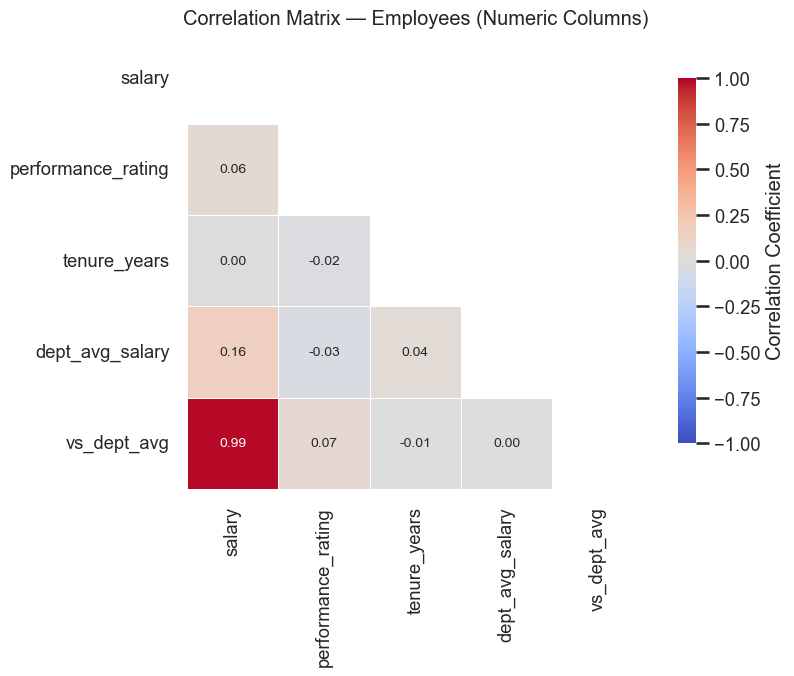

In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Load the Employees sheet
df = pd.read_excel("TechCorp_Cleaned.xlsx", sheet_name="Employees")

# Step 2: Select only the numeric columns that are MEANINGFUL to correlate.
# We deliberately EXCLUDE employee_id, manager_id, and hire_year here —
# these are identifiers/dates, not measurements, so correlating them
# would produce meaningless or misleading numbers.
numeric_cols = ["salary", "performance_rating", "tenure_years",
                 "dept_avg_salary", "vs_dept_avg"]

# Step 3: Compute the correlation matrix — a 5x5 grid of Pearson coefficients
corr_matrix = df[numeric_cols].corr()

# Step 4: Build a mask to hide the redundant upper triangle
# (corr_matrix is symmetric: correlation of A-B equals B-A, so showing
# both halves is visual duplication)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Step 5: Global theme/context
sns.set_theme(style="white")
sns.set_context("talk", font_scale=0.8)

plt.figure(figsize=(9, 7))

# Step 6: Draw the heatmap
sns.heatmap(
    data=corr_matrix,
    mask=mask,               # hide upper triangle (redundant mirror)
    vmin=-1, vmax=1,          # fix color scale to correlation's true theoretical range
    cmap="coolwarm",          # diverging colormap: blue = negative, red = positive
    center=0,                  # 0 correlation = neutral/pale color
    annot=True,                # print the actual coefficient in each cell
    fmt=".2f",                  # always show 2 decimal places
    annot_kws={"size": 10},
    linewidths=0.5,             # thin gridlines between cells
    linecolor="white",
    square=True,                 # force perfectly square cells
    cbar_kws={"label": "Correlation Coefficient", "shrink": 0.8}
)

plt.title("Correlation Matrix — Employees (Numeric Columns)")
plt.tight_layout()
plt.show()